# Volatility surface su SPY: analisi

Il notebook raccoglie i risultati del progetto. La sezione 1 si ricalcola a ogni esecuzione sui dati scaricati in quel momento (i grafici salvati nel file sono quelli dell'ultima esecuzione); le sezioni 2–4 usano le serie storiche in `data/`. Non calcola nulla di nuovo: usa le funzioni di `src/volsurf`
sui dati in `data/` (i passaggi e le scelte sono spiegati nel README). Tre domande:
1. Che forma ha la superficie di volatilità implicita di SPY (chain dell'ultima seduta disponibile)?
2. La volatilità implicita è in media sopra quella realizzata?
3. Vendere una call e coprirla in delta ha prodotto un guadagno, sui dati storici?

In [1]:
import sys
sys.path.insert(0, "../src")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from volsurf import svi, surface, realized, stat, backtest as bt, synthetic as sy
from volsurf.dati import leggi
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})

## 1. La superficie
Quote OTM per strike (put sotto il forward, call sopra), IV americana ricavata da un albero binomiale CRR, un fit SVI per scadenza.

In [2]:
import subprocess
from pathlib import Path
def esegui(script, *args):
    return subprocess.run([sys.executable, f"scripts/{script}", *args], cwd="..", capture_output=True, text=True)

# analisi corrente: scarica la chain dell'ultima seduta (serve la rete) e ricostruisce la superficie
if esegui("scarica_dati.py", "--solo-chain").returncode != 0:
    print("download non riuscito: uso gli ultimi dati scaricati")
esegui("costruisci_superficie.py").check_returncode()
d = pd.read_csv("../output/chain_finale_SPY.csv")
fits = svi.fit_chain(d)
sup = surface.Superficie.da_chain(d)
d["k"] = np.log(d["K"] / d["F"])
print(f"{len(d)} quote, {d['T'].nunique()} scadenze, spot {d['S'].iloc[0]:.2f}")

download non riuscito: uso gli ultimi dati scaricati


2467 quote, 17 scadenze, spot 769.64


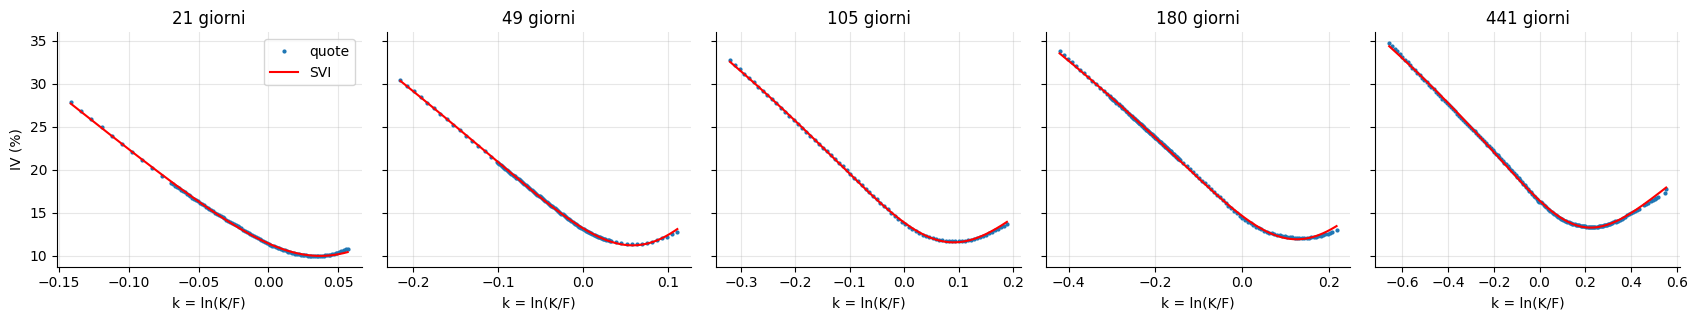

In [3]:
Ts = fits.index[np.linspace(1, len(fits) - 1, 5).astype(int)]
fig, ax = plt.subplots(1, 5, figsize=(17, 3.3), sharey=True)
for a, T in zip(ax, Ts):
    x = d[d["T"] == T]
    p = svi.SVI(*fits.loc[T, ["a", "b", "rho", "m", "sigma"]])
    k = np.linspace(x["k"].min(), x["k"].max(), 200)
    a.plot(x["k"], x["iv"] * 100, ".", ms=4, label="quote")
    a.plot(k, np.sqrt(svi.w(k, p) / T) * 100, "r", lw=1.5, label="SVI")
    a.set_title(f"{T*365:.0f} giorni"); a.set_xlabel("k = ln(K/F)")
ax[0].set_ylabel("IV (%)"); ax[0].legend()
plt.tight_layout(); plt.show()

Lo smile ha lo skew tipico dell'indice azionario: la IV sale per strike bassi (put OTM, domanda di protezione) e scende verso i call.

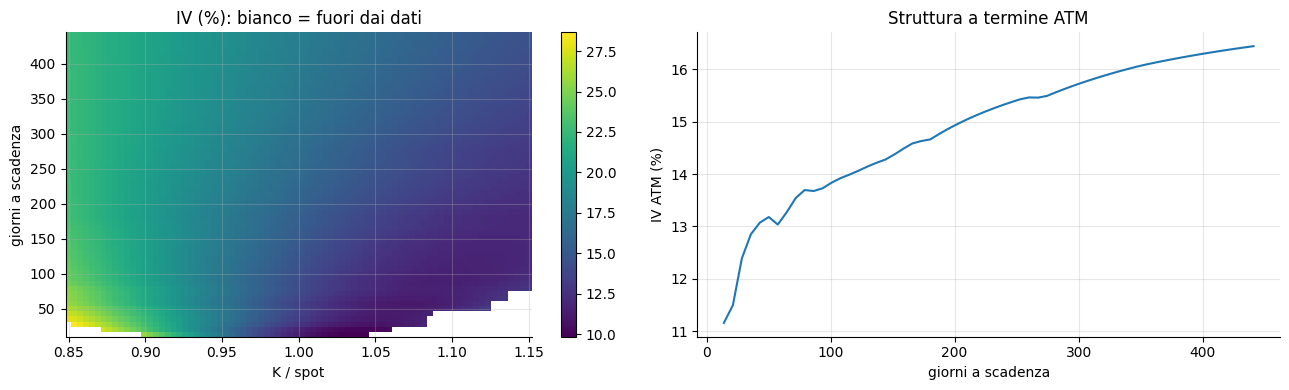

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
Tg = np.linspace(fits.index[0], fits.index[-1], 60)
Kg = np.linspace(0.85, 1.15, 80) * d["S"].iloc[0]
Z = np.array([sup.iv(Kg, T) for T in Tg]) * 100
im = ax[0].pcolormesh(Kg / d["S"].iloc[0], Tg * 365, Z, shading="auto", cmap="viridis")
ax[0].set_xlabel("K / spot"); ax[0].set_ylabel("giorni a scadenza"); ax[0].set_title("IV (%): bianco = fuori dai dati")
plt.colorbar(im, ax=ax[0])
atm = [sup.iv(sup.forward(T), T) * 100 for T in Tg]
ax[1].plot(Tg * 365, atm); ax[1].set_xlabel("giorni a scadenza"); ax[1].set_ylabel("IV ATM (%)"); ax[1].set_title("Struttura a termine ATM")
plt.tight_layout(); plt.show()

In [5]:
print("Arbitraggio butterfly: min g(k) sui dati per scadenza (>= 0 = ok):", fits["g_dati"].min().round(3))
print("Arbitraggio calendar: min w(T_j+1) - w(T_j) sul dominio comune:", round(svi.calendar_min(fits), 5))
print("Scadenze con parametri al limite del fit:", int(fits["al_limite"].sum()), "su", len(fits))

Arbitraggio butterfly: min g(k) sui dati per scadenza (>= 0 = ok): 0.119
Arbitraggio calendar: min w(T_j+1) - w(T_j) sul dominio comune: 0.00014
Scadenze con parametri al limite del fit: 4 su 17


La superficie esiste solo dove ci sono quotazioni. Sulle scadenze più brevi (nell'esecuzione salvata le prime quattro, fino a 35 giorni) i dati coprono poco e il fit SVI
è meno stabile (parametri al limite): lì la superficie è un'estrapolazione e per questo `iv` restituisce NaN fuori dal dominio.
Il controllo butterfly (condizione di Durrleman) è soddisfatto sui dati di tutte le scadenze; fuori dai dati, sulle scadenze corte, lo SVI lo viola, un altro motivo per non usare quelle zone.

## 2. IV contro volatilità realizzata
Serie storica di 8 anni di SPY. IV e VIX sono a 30 giorni di calendario (base 365), la vol realizzata è in giorni di borsa (base 252): porto prima la IV alla base 252 (fattore 0.9931), altrimenti il premio risulterebbe sovrastimato di circa 0.1 punti. Per ogni giorno si confronta la IV a 30 giorni (fornitore DoltHub) e il VIX con la volatilità realizzata nei 21 giorni di borsa successivi.

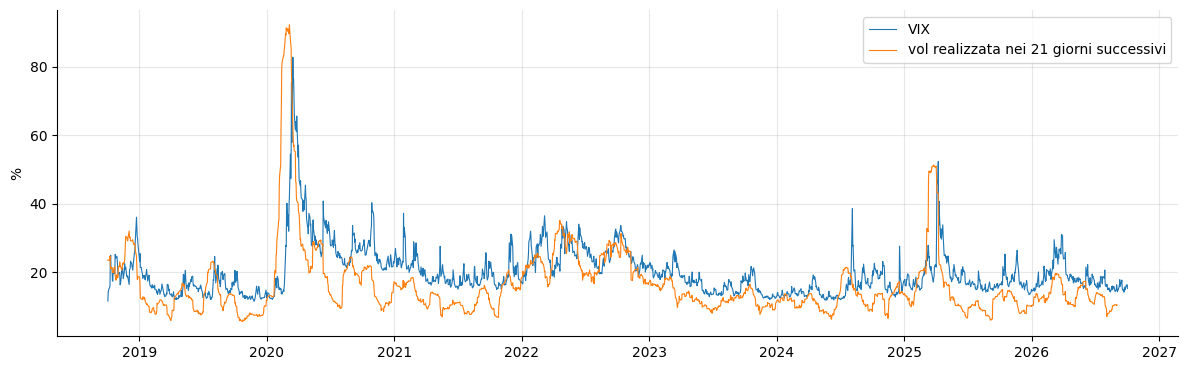

In [6]:
ohlc = leggi("../data/storico_SPY.csv")
px = ohlc["Close"]
iv = leggi("../data/dolthub/vol_SPY.csv")["iv_current"].astype(float)
iv = iv[(iv > .03) & (iv < 3)].reindex(px.index)
vix = leggi("../data/vix.csv")["Close"].reindex(px.index) / 100
G = 21
c = realized.iv_in_tempo_di_borsa          # IV e VIX sono a 30 giorni di calendario (base 365): li porto alla base 252
rv = pd.Series(realized.close_to_close(px.values, G), index=px.index)
rv_fut = rv.shift(-G)
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(vix * 100, lw=.8, label="VIX"); ax.plot(rv_fut * 100, lw=.8, label="vol realizzata nei 21 giorni successivi")
ax.set_ylabel("%"); ax.legend(); plt.tight_layout(); plt.show()

In [7]:
righe = {}
for nome, x in {"VIX - RV": c(vix, G) - rv_fut, "VIX - RV (solo giorni con IV)": (c(vix, G) - rv_fut)[iv.notna()],
                "IV 30gg - RV": c(iv, G) - rv_fut}.items():
    x = x.dropna() * 100
    m, se, t = stat.media_hac(x, G)
    righe[nome] = dict(n=len(x), media_pt=m, se_NW=se, t=t, giorni_positivi=(x > 0).mean())
pd.DataFrame(righe).T.round(2)

,n,media_pt,se_NW,t,giorni_positivi
VIX - RV,1989.0,3.54,0.76,4.64,0.83
VIX - RV (solo giorni con IV),1157.0,3.66,0.90,4.05,0.85
IV 30gg - RV,1157.0,0.42,0.89,0.47,0.69


Il VIX sta in media circa 3.5 punti sopra la vol realizzata (t ≈ 4.6), ma il VIX è una stima del prezzo di uno swap sulla varianza
dell'S&P 500, non la IV di una call at-the-money: include il premio di varianza degli strike bassi. Per la IV ATM a 30 giorni il
premio è molto più piccolo (circa 0.4 punti) e statisticamente non distinguibile da zero. Gli errori standard sono Newey-West perché le finestre di 21 giorni si sovrappongono.

## 3. Backtest: call venduta e coperta in delta
Ogni giorno si vende una call at-the-forward a 21 giorni di borsa, prezzata con la IV a 30 giorni di quel giorno, e la si copre in delta ogni giorno fino a scadenza. P&L in % dello spot, r e q costanti.

1157 operazioni, P&L medio +0.070% (se NW 0.056, t +1.24), in guadagno 66%


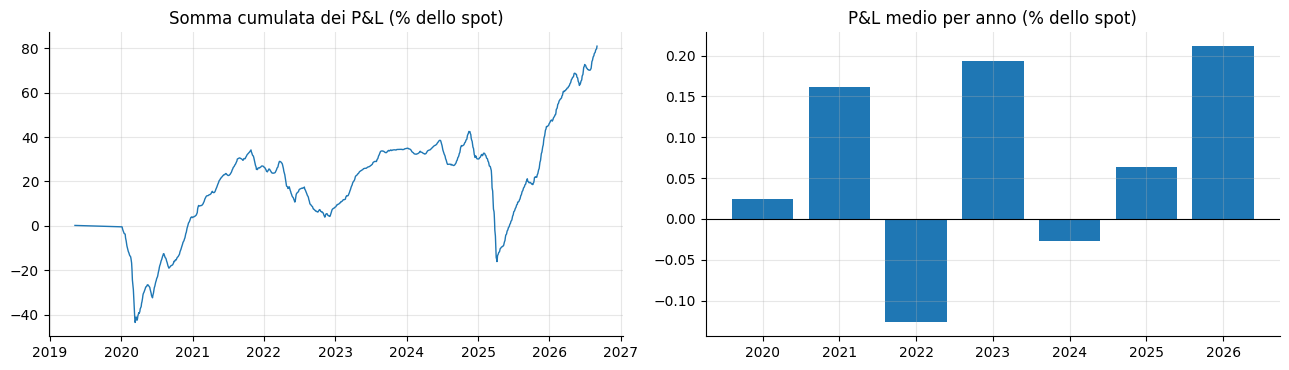

In [8]:
R, Q = 0.03, 0.013
df = bt.backtest_reale(px.values, c(iv, G).values, G, R, Q)
df["data"] = px.index[df["t0"].values]; df["anno"] = df["data"].dt.year
m, se, t = stat.media_hac(df["pnl"], G)
print(f"{len(df)} operazioni, P&L medio {m:+.3f}% (se NW {se:.3f}, t {t:+.2f}), in guadagno {(df['pnl']>0).mean():.0%}")
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
ax[0].plot(df["data"], df["pnl"].cumsum(), lw=1)
ax[0].set_title("Somma cumulata dei P&L (% dello spot)")
por_anno = df.groupby("anno")["pnl"].agg(["mean", "count"]).query("count > 30")
ax[1].bar(por_anno.index, por_anno["mean"]); ax[1].axhline(0, c="k", lw=.8)
ax[1].set_title("P&L medio per anno (% dello spot)")
plt.tight_layout(); plt.show()

Il P&L medio è positivo ma piccolo rispetto alla sua variabilità (0.07% contro una deviazione standard di circa 0.6%), e non è stabile: è negativo nel 2022 e circa zero nel 2024 e nel 2020, l'anno con la dispersione maggiore.
Il grafico cumulato non è un'equity curve eseguibile, perché gli ingressi giornalieri si sovrappongono: serve solo a vedere dove si accumula il guadagno e dove si perde.

In [9]:
righe = {}
for sh in (0, -.5, -.73, -1.0):
    x = bt.backtest_reale(px.values, c(iv + sh / 100, G).values, G, R, Q)
    m, se, t = stat.media_hac(x["pnl"], G)
    righe[f"IV {sh:+.2f} pt"] = dict(media=m, se_NW=se, t=t)
for cs in (0, 1e-4, 3e-4):
    x = bt.backtest_reale(px.values, c(iv, G).values, G, R, Q, costo=cs)
    m, se, t = stat.media_hac(x["pnl"], G)
    righe[f"costo {cs*1e4:.0f} bp"] = dict(media=m, se_NW=se, t=t)
pd.DataFrame(righe).T.round(3)

,media,se_NW,t
IV +0.00 pt,0.070,0.056,1.243
IV -0.50 pt,0.012,0.056,0.222
IV -0.73 pt,-0.014,0.055,-0.256
IV -1.00 pt,-0.045,0.055,-0.824
costo 0 bp,0.070,0.056,1.243
costo 1 bp,0.045,0.056,0.793
costo 3 bp,-0.006,0.056,-0.113


La nostra IV (calcolata dalla chain con albero americano) risulta circa 0.7 punti sotto quella del fornitore: causa non spiegata. Se si vende a quella IV invece che a quella del fornitore,
il guadagno medio scompare (diventa leggermente negativo). Con costi di 1 punto base per ribilanciamento si riduce a circa la metà; per SPY 1 punto base è una stima prudente. **Conclusione: sui dati storici un vantaggio non è dimostrato**; il segnale è debole e dentro il margine d'errore di come si misura la IV.

## 4. Mondo sintetico: perché la copertura non basta
Con un modello di Heston noto (i parametri veri sono noti) si vede cosa ci si dovrebbe aspettare: l'effetto della frequenza di copertura e dei costi su una call venduta a 21 giorni.

In [10]:
M = sy.Mondo()
S, V = sy.simulate_P(M, 1260, n_paths=100, seed=7)
righe = {}
for o in (1, 2, 5, 10):
    x = bt.backtest(M, S, V, 21, ogni=o)
    ic = bt.media_con_ic(x)
    righe[f"ogni {o} gg"] = dict(media=ic["media"], ic_basso=ic["ic_basso"], ic_alto=ic["ic_alto"], dev_std=x["pnl"].std())
pd.DataFrame(righe).T.round(3)

,media,ic_basso,ic_alto,dev_std
ogni 1 gg,0.051,0.037,0.065,0.533
ogni 2 gg,0.049,0.032,0.065,0.657
ogni 5 gg,0.056,0.033,0.080,0.899
ogni 10 gg,0.059,0.029,0.089,1.190


Con ribilanciamento meno frequente la media non cambia molto, ma la dispersione del P&L aumenta (l'errore di copertura cresce con l'intervallo fra due ribilanciamenti). Coprire ogni giorno riduce il rischio, non crea il premio:
il premio c'è solo se la IV a cui si vende è sopra la volatilità che poi si realizza.